# Can you answer Meera's three questions alone in fifty minutes, and ship a note under 200 words that survives Marketing?

**Week 1, Thursday afternoon. The escalated case: 50 minutes, alone, straight after chapter 6.** Five
parts, twelve lettered choices, and a note of under 200 words at the end.

> **The client asks.** "One: Retail-Plus is down, smaller than first reported. Real, or the wobble we
> see every quarter? Two: Student is up 40 percent; should I move budget there? Three: marketing ran a
> monsoon-sale discount for Retail-Plus in August, says it lifted revenue 6 percent, and wants to
> repeat it for Diwali. Did the discount work, or did those customers buy anyway? One page, two
> minutes. If the honest answer is 'we do not know yet', say so and tell me what would tell us."
>
> Meera Raghavan, CEO, Kalpa Retail

**Who needs the answer.** Meera reads the page in two minutes before Monday's growth review, with the
marketing lead in the room ready to defend the monsoon sale. A line without its base sends money the
wrong way: a retention budget for a fall chance could have made, acquisition budget moved on a rate
whose count nobody checked, or a Diwali sale at 15 percent off for customers who would have bought
anyway.

**The questions on the way.**

1. Is the Retail-Plus fall larger than the wobble chance makes, counted in both directions?
2. How big is the fall against the company's quarter, and who gets the first test of the offer?
3. How many orders stand behind Student's 40 percent, and how often does chance make the rise?
4. Did the monsoon sale lift spend, and for whom?
5. How many customers does the Diwali hold-back keep out, and what does the note say?

Kalpa Retail sells through its app, its website and its stores, to four segments: Retail-Core and
Retail-Plus, its two consumer tiers, of which Retail-Plus is the paid membership; Student; and
Business, its sales to companies. The setup cell below loads the day's three files: Finance's
cleaned orders, 186 orders across Q1 and Q2; the campaign platform's August list, the exposure
table, 160 customers flagged by whether they got the sale; and the campaigns table, one campaign.
Revenue here is the money Kalpa kept, as Monday defined it, and recalling which orders that covers
is marker 1's question. The six chapters answered Meera's questions one at a time on these files,
and this case asks you to rebuild the answers alone, choosing every step, and to write them up.
Chapter 1 set a chance reference against the Retail-Plus fall and read its share both ways, chapter
2 sized the fall in rupees against the company and against a retention offer, chapter 3 counted what
Student's rate stands on, chapter 4 rebuilt Marketing's 6 percent and asked who got the sale,
chapter 5 wrote the four-part note, and chapter 6 asked what else changed in August and priced a
hold-back for Diwali.

A chance reference is a set of invented worlds in which nothing changed. The setup cell's `flip_gaps`
builds them by letting a coin decide, for each pair of values, which one counts as the first;
`shuffle_gaps` pools every value and deals it into two piles at random; `flip_rises` deals a count of
orders between two quarters by a coin per order. The share is the fraction of those worlds that make
a gap at least as large as the real one, counted for falls only or for a move that large in either
direction. A retention offer is a payment or perk meant to win back members' spend, assumed at Rs 500
a member a quarter. The rule of thumb from chapter 3 is to distrust a rate with fewer than thirty
customers behind it. A blend is one average across segments mixed together, a group's mix is its
make-up by segment, and a lift is how much more one group spent than another, as a share of the
other's spend. A hold-back is a group that a coin keeps out of a sale, so the rest can be compared
with it afterwards. The note has four parts: claim, evidence, caveat and action.

**This is the solution.** Every choice is filled with its key line, the notebook runs clean from a fresh
kernel, and the reason for each letter follows the cell that carries it.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
EXPOSURE = kit.load_csv("C2_W01_D04_exposure_STUDENT.csv")
CAMPAIGNS = kit.load_csv("C2_W01_D04_campaigns_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def flip_gaps(q1, q2, times, seed):
    """A coin for each pair decides which of its two values counts in the first list; the gap in means, many times."""
    random.seed(seed)
    diffs = [a - b for a, b in zip(q1, q2)]
    return [mean([d if random.random() < 0.5 else -d for d in diffs]) for _ in range(times)]


def shuffle_gaps(q1, q2, times, seed):
    """Every value in one pool, dealt at random into two piles of the original sizes; the gap in means, many times."""
    random.seed(seed)
    pool = q1 + q2
    gaps = []
    for _ in range(times):
        random.shuffle(pool)
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def flip_rises(n_orders, times, seed):
    """Deal each of n orders to Q1 or Q2 by a fair coin, many times, and keep each rise."""
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises


print(len(ORDERS), "orders in Finance's file,", len(EXPOSURE), "customers on the platform's list,", len(CAMPAIGNS), "campaign")

186 orders in Finance's file, 160 customers on the platform's list, 1 campaign


## Part 1. Is the Retail-Plus fall larger than the wobble chance makes, counted in both directions?

Used at work whenever a metric moves between two reviews and someone asks whether it moved at all.

The same 22 Retail-Plus members sit in both quarters. Choose which orders count, the chance
reference that fits members measured twice, and the count for a move that large in either direction.
Meera's question arrived after the fall was seen, so both directions go in the note.

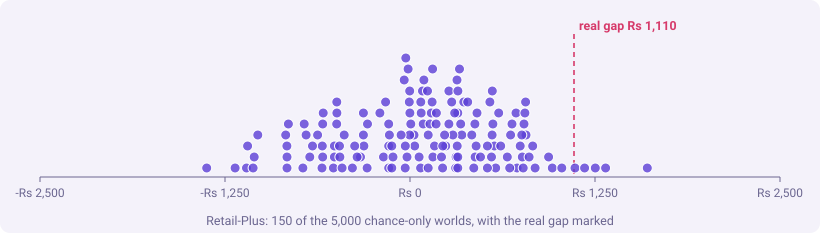

real gap Rs 1,110 per member; falls only 0.029; either way 0.057


In [2]:
def kept(o):
    # TODO 1. Which orders count as money Kalpa kept?
    #   a) o["status"] != "cancelled"
    #   b) o["status"] == "delivered"
    #   c) o["amount"] != ""
    #   d) o["status"] in ("delivered", "returned")
    return o["status"] == "delivered"


def member_totals(segment, quarter):
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and kept(o):
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
plus_gap = mean(plus_q1) - mean(plus_q2)
# TODO 2. The same 22 members sit in both quarters. Which chance reference fits?
#   a) shuffle_gaps(plus_q1, plus_q2, 5000, seed=2026)
#   b) flip_rises(len(plus_q1), 5000, seed=2026)
#   c) flip_gaps(plus_q1, plus_q2, 5000, seed=2026)
#   d) shuffle_gaps(plus_q1, plus_q1, 5000, seed=2026)
gaps = flip_gaps(plus_q1, plus_q2, 5000, seed=2026)
falls_share = sum(1 for g in gaps if g >= plus_gap) / len(gaps)
# TODO 3. Which count gives the share of a move that large in either direction?
#   a) sum(1 for g in gaps if g <= plus_gap) / len(gaps)
#   b) sum(1 for g in gaps if abs(g) >= abs(plus_gap)) / len(gaps)
#   c) sum(1 for g in gaps if abs(g) <= abs(plus_gap)) / len(gaps)
#   d) 2 * sum(1 for g in gaps if g >= plus_gap) / len(gaps)
either_share = sum(1 for g in gaps if abs(g) >= abs(plus_gap)) / len(gaps)
kit.strip(gaps[:150], markers=[("real gap", plus_gap, "bad")], lo=-2500, hi=2500,
          title="Retail-Plus: 150 of the 5,000 chance-only worlds, with the real gap marked")
print(f"real gap Rs {plus_gap:,.0f} per member; falls only {falls_share:.3f}; either way {either_share:.3f}")

**TODO 1 is b.** Monday settled that delivered orders are the money Kalpa kept. a keeps returned orders, whose money went back; c keeps every order, cancelled ones included; d counts returns as sales.

**TODO 2 is c.** The same members sit in both quarters, so the chance reference flips each member's own pair. a pools the 44 totals as if they were 44 different customers, which is the test for two groups of strangers; b deals orders by coin, the reference for a count of orders; d shuffles Q1 against itself, so no gap can appear.

**TODO 3 is b.** A move that large either way is a flip whose size, up or down, reaches the real gap. a counts every gap at or below the real one, which is nearly every world; c counts moves at most that large, the complement; d doubles the one-direction share, which lands near the count here (0.058) and is still an estimate where the count is exact.

In [3]:
kit.check("the real gap is Rs 1,110 per member", round(plus_gap) == 1110, f"{plus_gap:,.1f}")
kit.check("counting falls only, the share is 0.029 with seed 2026", round(falls_share, 3) == 0.029, f"{falls_share:.4f}")
kit.check("counting either way, the share is 0.057 with seed 2026", round(either_share, 3) == 0.057, f"{either_share:.4f}")

## Part 2. How big is the fall against the company's quarter, and who gets the first test of the offer?

Used at work whenever a team asks for a budget to fix a fall, before anyone signs it off.

The retention offer is assumed at Rs 500 a member a quarter. It is sized on Finance's order file,
where the tier is these 22 members, and the fall is borderline, so the first step is a test.

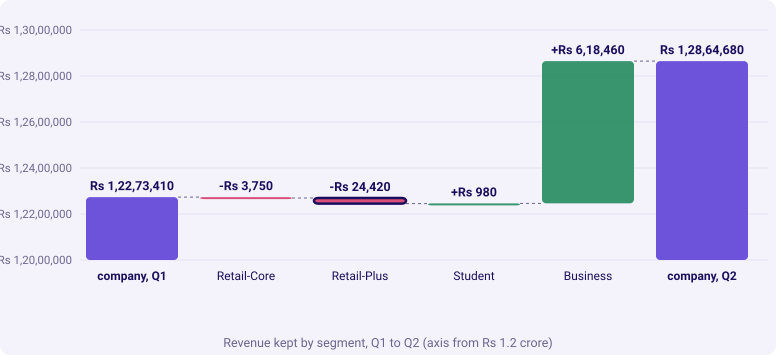

the fall Rs 24,420 a quarter; the test offers 11 members and holds back 11


In [4]:
def revenue(segment, quarter):
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and kept(o))


company_q1 = sum(revenue(s, "Q1") for s in SEGMENTS)
company_q2 = sum(revenue(s, "Q2") for s in SEGMENTS)
# TODO 4. What is the segment's fall in rupees a quarter?
#   a) plus_gap * len(plus_q1)
#   b) plus_gap
#   c) plus_gap / len(plus_q1)
#   d) sum(plus_q1) - plus_gap * 100
plus_fall = plus_gap * len(plus_q1)
# TODO 5. What is the fall measured against, for Meera?
#   a) sum(plus_q1)
#   b) len(ORDERS)
#   c) revenue("Retail-Core", "Q2")
#   d) company_q2
share_of_company = plus_fall / company_q2

members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == "Retail-Plus"})
fall_by_member = dict(zip(members, [a - b for a, b in zip(plus_q1, plus_q2)]))
random.seed(2026)
coin_half = sorted(random.sample(members, len(members) // 2))
fell_most = sorted(members, key=lambda m: -fall_by_member[m])[:len(members) // 2]
# TODO 6. The fall is borderline and the offer costs Rs 500 a member. Who gets it in the first test?
#   a) members
#   b) fell_most
#   c) coin_half
#   d) members[:len(members) // 2]
offered = coin_half
held_back = [m for m in members if m not in offered]
kit.bridge(("company, Q1", company_q1), [(s, revenue(s, "Q2") - revenue(s, "Q1")) for s in SEGMENTS],
           end_label="company, Q2", lo=12_000_000, lit=[1], title="Revenue kept by segment, Q1 to Q2 (axis from Rs 1.2 crore)")
print(f"the fall {kit.rupees(round(plus_fall))} a quarter; the test offers {len(offered)} members and holds back {len(held_back)}")

**TODO 4 is a.** A per-member gap times the members who exist in both quarters is the segment's fall. b is still per member; c divides again; d mixes a total with a gap.

**TODO 5 is d.** Meera runs the company, so the fall is set against the company's quarter. a sizes it against the tier's own Q1, which is the head of Retail-Plus's view; b is a count of orders; c sets it against another segment.

**TODO 6 is c.** A borderline fall and an offer that must win back 45 percent call for a test, and a coin makes the two halves alike before the offer, so any gap after it belongs to the offer. a spends Rs 11,000 and leaves nobody to compare with; b offers it to the members who fell most, who also spent most in Q1, so the halves start Rs 2,490 apart and drift back toward the average whatever the offer does; d splits by customer id, which here puts the bigger Q1 spenders on one side, Rs 1,025 apart.

In [5]:
q1_by_member = dict(zip(members, plus_q1))
apart = (abs(mean([q1_by_member[m] for m in offered]) - mean([q1_by_member[m] for m in held_back]))
         if offered and held_back else float("inf"))
kit.check("the fall is Rs 24,420 a quarter", round(plus_fall) == 24420, kit.rupees(round(plus_fall)))
kit.check("the fall is 0.19 percent of the base Meera sets it against", round(share_of_company, 4) == 0.0019,
          f"{share_of_company:.2%}")
kit.check("the first test costs Rs 5,500 a quarter and holds back as many members as it offers",
          500 * len(offered) == 5500 and len(held_back) == len(offered), kit.rupees(500 * len(offered)))
kit.check("the offered and held-back halves spent within Rs 500 of each other in Q1", apart < 500,
          "nobody held back" if apart == float("inf") else f"Rs {apart:,.0f} apart")

## Part 3. How many orders stand behind Student's 40 percent, and how often does chance make the rise?

Used at work on every leaderboard of stores, cities or segments ranked by a rate.

The count is yours to find, and nothing below prints it: the check cell reaches it through the shares
it drives. The coin flips count orders; the rule of thumb counts customers, since more orders from the
same few customers add no new evidence.

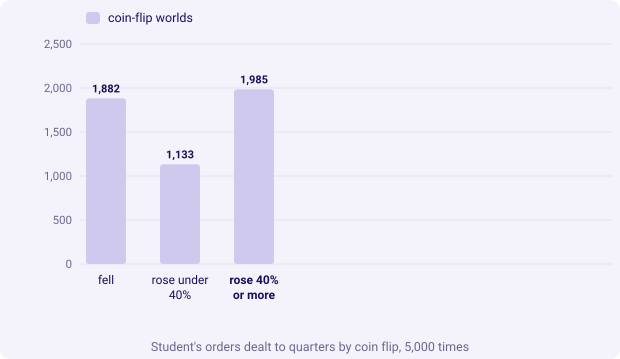

In [6]:
def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


index_student = round(100 * orders_in("Student", "Q2") / orders_in("Student", "Q1"))
# TODO 7. How many orders stand behind Student's 40 percent, for the coin flips?
#   a) orders_in("Student", "Q2")
#   b) sum(1 for o in ORDERS if o["segment"] == "Student")
#   c) index_student
#   d) orders_in("Student", "Q2") - orders_in("Student", "Q1")
student_n = sum(1 for o in ORDERS if o["segment"] == "Student")
# TODO 8. Which chance reference fits a count of orders?
#   a) flip_rises(student_n, 5000, seed=2026)
#   b) flip_gaps([student_n], [0], 5000, seed=2026)
#   c) flip_rises(400, 5000, seed=2026)
#   d) [0.4] * 5000
rises = flip_rises(student_n, 5000, seed=2026)
student_share = sum(1 for r in rises if r >= 0.4 - 1e-9) / len(rises)
kit.columns(["fell", "rose under 40%", "rose 40% or more"],
            [("coin-flip worlds", [sum(1 for r in rises if r < 0), sum(1 for r in rises if 0 <= r < 0.4 - 1e-9),
                                   sum(1 for r in rises if r >= 0.4 - 1e-9)])],
            lit=[2], width=620, title="Student's orders dealt to quarters by coin flip, 5,000 times")

**TODO 7 is b.** The coin flips deal every order the rate stands on, both quarters together. a counts only Q2; c is the rate itself; d is the change between the quarters. The rule of thumb then asks how many customers placed those orders, which the note reports in words.

**TODO 8 is a.** A coin flip per order on Student's own count is the chance reference for a count. b treats the count as one member's two quarters; c deals 400 orders, the size chapter 3 invented for a large segment; d assumes the answer.

In [7]:
from math import comb

exact = sum(comb(student_n, k) for k in range(student_n + 1)
            if k == student_n or k / (student_n - k) - 1 >= 0.4 - 1e-9) / 2 ** student_n
kit.check("Student's orders rose 40 percent", index_student == 140)
kit.check("every deal of your count, listed exactly, makes the rise in 0.387 of them", round(exact, 3) == 0.387,
          f"{exact:.3f}")
kit.check("your chance reference makes the rise in 0.397 of worlds with seed 2026", round(student_share, 3) == 0.397,
          f"{student_share:.3f}")

## Part 4. Did the monsoon sale lift spend, and for whom?

Used at work on every campaign readout, before anyone runs the campaign again.

The exposure table is the campaign platform's August list: the 160 Retail-Plus and Retail-Core
customers the platform held, under the platform's own customer ids, with one average August spend
for each group. It records who received the sale, whatever the sale was aimed at, which is why it
counts Retail-Core customers among them although the campaigns table aimed the sale at Retail-Plus.
It cannot be matched to Finance's order file, whose 22 Retail-Plus members and discount column carry
no record of the sale. Read it for who got the sale and how the two groups differ.

blended: exposed Rs 3,395 against Rs 3,200, +6.1%


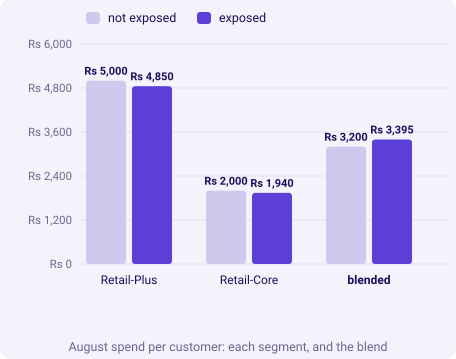

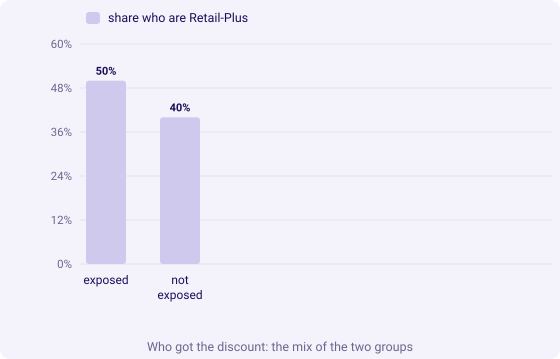

In [8]:
# TODO 9. Which rows are the customers who got the discount?
#   a) r["campaign_id"] == ""
#   b) r["segment"] == "Retail-Plus"
#   c) int(r["august_revenue"]) > 3200
#   d) r["exposed"] == "yes"
exposed = [r for r in EXPOSURE if r["exposed"] == "yes"]
others = [r for r in EXPOSURE if r not in exposed]
blend_yes = mean([int(r["august_revenue"]) for r in exposed])
blend_no = mean([int(r["august_revenue"]) for r in others])
blend_lift = blend_yes / blend_no - 1
print(f"blended: exposed {kit.rupees(blend_yes)} against {kit.rupees(blend_no)}, {blend_lift:+.1%}")


def avg(segment, flag):
    return mean([int(r["august_revenue"]) for r in EXPOSURE if r["segment"] == segment and r["exposed"] == flag])


def count(flag, segment=None):
    return sum(1 for r in EXPOSURE if r["exposed"] == flag and (segment is None or r["segment"] == segment))


# TODO 10. Marketing will read this comparison first. Which one is fair?
#   a) {s: avg(s, "yes") / blend_no - 1 for s in ["Retail-Plus", "Retail-Core"]}
#   b) {s: avg(s, "yes") / avg(s, "no") - 1 for s in ["Retail-Plus", "Retail-Core"]}
#   c) {"everyone": blend_lift}
#   d) {s: avg(s, "yes") / avg("Retail-Plus", "no") - 1 for s in ["Retail-Plus", "Retail-Core"]}
within = {s: avg(s, "yes") / avg(s, "no") - 1 for s in ["Retail-Plus", "Retail-Core"]}
# TODO 11. What share of the exposed customers are Retail-Plus members?
#   a) count("yes", "Retail-Plus") / count("yes")
#   b) count("no", "Retail-Plus") / count("no")
#   c) count("yes", "Retail-Plus") / len(EXPOSURE)
#   d) count("yes") / len(EXPOSURE)
plus_mix_exposed = count("yes", "Retail-Plus") / count("yes")
plus_mix_others = count("no", "Retail-Plus") / count("no")
kit.columns(["Retail-Plus", "Retail-Core", "blended"],
            [("not exposed", [avg("Retail-Plus", "no"), avg("Retail-Core", "no"), round(blend_no)]),
             ("exposed", [avg("Retail-Plus", "yes"), avg("Retail-Core", "yes"), round(blend_yes)])],
            fmt=kit.rupees, lit=[2], title="August spend per customer: each segment, and the blend")
kit.columns(["exposed", "not exposed"], [("share who are Retail-Plus", [round(100 * plus_mix_exposed), round(100 * plus_mix_others)])],
            fmt=lambda v: f"{v:.0f}%", width=560, title="Who got the discount: the mix of the two groups")

**TODO 9 is d.** The exposure flag records who got the discount. a picks the customers with no campaign, the opposite group; b picks a segment; c picks customers by what they spent, which is the outcome being measured.

**TODO 10 is b.** The fair comparison runs inside each segment, exposed against unexposed customers of the same kind. a sets each segment's exposed against every unexposed customer, the comparison Marketing makes in the second case; c is the blend again; d sets Retail-Core's exposed against Retail-Plus's unexposed.

**TODO 11 is a.** Retail-Plus members over all exposed customers is the mix of the exposed group. b is the unexposed group's mix; c divides by every customer on the list; d is the exposed share of the list.

In [9]:
kit.check("the blend rises 6.1 percent, as Marketing reported", round(blend_lift, 3) == 0.061, f"{blend_lift:+.1%}")
kit.check("the fair comparison finds 3.0 percent less in each of the two segments",
          sorted(round(v, 3) for v in within.values()) == [-0.03, -0.03],
          ", ".join(f"{s} {v:+.1%}" for s, v in within.items()))
kit.check("half of the exposed customers are Retail-Plus members", round(plus_mix_exposed, 2) == 0.5, f"{plus_mix_exposed:.0%}")

## Part 5. How many customers does the Diwali hold-back keep out, and what does the note say?

Used at work whenever a team plans a campaign it will have to prove afterwards, and whenever a CEO
wants the answer on one page.

Marketing wants the sale again at Diwali. A coin will keep one in five customers out of it, inside
each segment, so the rest can be compared with them afterwards. Choose whom the coin draws from.

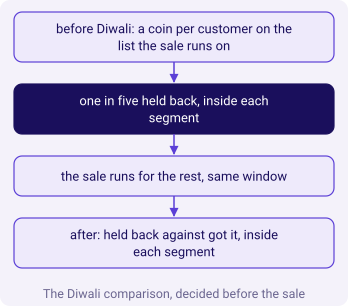

In [10]:
finance_members = plus_q1                                  # Finance's order file: one total per Retail-Plus member
platform_plus = [r for r in EXPOSURE if r["segment"] == "Retail-Plus"]
platform_plus_exposed = [r for r in platform_plus if r["exposed"] == "yes"]
# TODO 12. How many Retail-Plus customers does the coin hold back?
#   a) len(finance_members) // 5
#   b) len(platform_plus_exposed) // 5
#   c) len(platform_plus) // 5
#   d) len(EXPOSURE) // 5
held = len(platform_plus) // 5
forgone = round(held * avg("Retail-Plus", "no") * 0.06)
kit.vflow(["before Diwali: a coin per customer on the list the sale runs on", "one in five held back, inside each segment",
           "the sale runs for the rest, same window", "after: held back against got it, inside each segment"],
          lit=1, title="The Diwali comparison, decided before the sale")
kit.stats([(f"{held}", "Retail-Plus held back", "one in five"),
           (kit.rupees(forgone), "forgone", "if Marketing's 6 percent were real")])

**TODO 12 is c.** The sale runs on the platform's list, so the hold-back is one in five of its Retail-Plus customers, exposed last time or not. a takes Finance's members, a different list with different ids; b samples only the customers Marketing picked last time; d takes both segments at once, so Retail-Plus's slice is no longer one in five.

In [11]:
kit.check("the hold-back forgoes about Rs 4,200 at Marketing's own 6 percent", forgone == 4200, kit.rupees(forgone))

## So what does the note to Meera say, in 190 words?

**Claim.** Retail-Plus is down by a borderline amount and small against the company; Student is too
thin to fund yet; the monsoon sale did not work as designed.

**Evidence.** Retail-Plus members delivered Rs 1,110 less each in Q2; if nothing had changed, a fall
that large turns up in about 3 of 100 flips, and a move that large either way in about 6. It is Rs
24,420 a quarter, 0.19 percent of delivered revenue. Student's 40 percent rise comes from very few
customers, and coin flips make it in four worlds of ten. The sale's 6 percent is a blend: inside
Retail-Plus and Retail-Core, exposed customers spent 3 percent less.

**Caveat.** We asked after seeing the fall. The group who got the sale was half Retail-Plus against
40 percent of the rest, and Retail-Plus spends more anyway; the platform's list gives one August
figure per group, so we cannot see the spread.

**Action.** Watch Retail-Plus, and if we act, test the offer on a coin-chosen half; watch Student until
more customers buy, thirty or more; do not repeat the sale as designed, and hold back a random slice
of each segment at Diwali.

In [12]:
note = """Retail-Plus is down by a borderline amount and small against the company; Student is too thin to
fund yet; the monsoon sale did not work as designed. Retail-Plus members delivered Rs 1,110 less each in
Q2; if nothing had changed, a fall that large turns up in about 3 of 100 flips, and a move that large
either way in about 6. It is Rs 24,420 a quarter, 0.19 percent of delivered revenue. Student's 40 percent
rise comes from very few customers, and coin flips make it in four worlds of ten. The sale's 6 percent is
a blend: inside Retail-Plus and Retail-Core, exposed customers spent 3 percent less. We asked after seeing
the fall. The group who got the sale was half Retail-Plus against 40 percent of the rest, and Retail-Plus
spends more anyway; the platform's list gives one August figure per group, so we cannot see the spread.
Watch Retail-Plus, and if we act, test the offer on a coin-chosen half; watch Student until more
customers buy, thirty or more; do not repeat the sale as designed, and hold back a random slice of each
segment at Diwali."""
words = len(note.split())
print(words, "words")
kit.check("the note is under 200 words", words < 200, f"{words}")
kit.check("the note gives each question a line", all(k in note for k in ("Retail-Plus", "Student", "sale")))
kit.check_summary()
print("Post the twelve letters in order, then read your note aloud to your partner.")

190 words


Post the twelve letters in order, then read your note aloud to your partner.
